# PART A: Dataset Analysis

In [1]:
#!rm -rf /kaggle/working/*

## INPUT FILES — Painter by Numbers Dataset

### all_data_info.csv
- Includes artist,date,genre,pixelsx,pixelsy,size_bytes,source,style,title,artist_group,in_train,new_filename
- artist_group field says if data is present only in train/test/in both

### replacements_for_corrupted_files.zip
- Contains the replacements for corrupted data
- 3 in test and 7 in train , total 10 to be replaced

### test.zip
- Images in the test set.

### train.zip
- Images in the train set.

### train_1.zip to train_9.zip
- subsets of train.zip.
- Dataset is split into multiple ZIPs to make downloading and processing easier.

### train_info.csv
- Metadata for training images.
- Includes filename,artist,title,style,genre,date.

## Importing All modules

In [2]:
# ===============================
# Standard Library Imports
# ===============================
import itertools
import os
import re
import shutil
import time
import zipfile
from datetime import datetime

# ===============================
# Utility & Progress Tracking
# ===============================
from tqdm import tqdm

# ===============================
# Data Handling & Numerical
# ===============================
import numpy as np
import pandas as pd

# ===============================
# Visualization
# ===============================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
matplotlib.rc_file_defaults()

# ===============================
# Image Processing
# ===============================
import cv2
from PIL import Image
from skimage.feature import hog

# ===============================
# Scikit-learn
# ===============================
from sklearn import preprocessing, svm
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ===============================
# PyTorch
# ===============================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, SubsetRandomSampler
from torchvision import models, transforms

## Loading data

In [3]:
path = '../input/painter-by-numbers/'
df = pd.read_csv(path+'all_data_info.csv')
df.head()

,artist,date,genre,pixelsx,pixelsy,size_bytes,source,style,title,artist_group,in_train,new_filename
0,Barnett Newman,1955.0,abstract,15530.0,6911.0,9201912.0,wikiart,Color Field Painting,Uriel,train_only,True,102257.jpg
1,Barnett Newman,1950.0,abstract,14559.0,6866.0,8867532.0,wikiart,Color Field Painting,Vir Heroicus Sublimis,train_only,True,75232.jpg
2,kiri nichol,2013.0,NaN,9003.0,9004.0,1756681.0,NaN,Neoplasticism,NaN,test_only,False,32145.jpg
3,kiri nichol,2013.0,NaN,9003.0,9004.0,1942046.0,NaN,Neoplasticism,NaN,test_only,False,20304.jpg
4,kiri nichol,2013.0,NaN,9003.0,9004.0,1526212.0,NaN,Neoplasticism,NaN,test_only,False,836.jpg


### Dataset details

In [4]:
print(f"The full dataset contains a total of {len(df['artist'].unique())} different artists and {len(df['genre'].unique())} unique painting genres.\n")
print(f"Total images: {len(df)}")

The full dataset contains a total of 2319 different artists and 43 unique painting genres.

Total images: 103250


# Data Cleaning :
## Corrupted Image Replacement

**What this code does:**
1. **Identifies corrupted images** - Reads original images from `train.zip` and `test.zip`
2. **Detects corruption** - Catches images that cannot be loaded (KeyError, UnidentifiedImageError, etc.)
3. **Replaces with fixed versions** - Loads replacement images from `replacements_for_corrupted_files.zip`
4. **Visualizes before/after** - Shows corrupted (black placeholder) vs fixed images side-by-side
5. **Reports statistics** - 10 corrupted images were successfully identified and fixed

In [5]:
archive = zipfile.ZipFile(path + 'replacements_for_corrupted_files.zip', 'r')
train_dir, test_dir = '/kaggle/working/train', '/kaggle/working/test'

corrupted_map = {
    item.split('/')[-1].replace('.jpg', ''): item
    for item in archive.namelist()
    if item.endswith('.jpg')
}

In [6]:
print("="*60)
print("STEP 1: REPLACING CORRUPTED FILES")
print("="*60)

# Create temporary directory for replacements
temp_replacement_dir = '/kaggle/working/temp_replacements'
os.makedirs(temp_replacement_dir, exist_ok=True)

# Open replacement zip (using your corrupted_map)
replacement_zip = zipfile.ZipFile(path + 'replacements_for_corrupted_files.zip', 'r')

# Filter out Mac OS hidden files (._*) and count unique corrupted files
unique_corrupted = set([img_id for img_id in corrupted_map.keys() if not img_id.startswith('._')])
print(f"\n🔧 Found {len(unique_corrupted)} unique corrupted files (filtered out Mac OS metadata)")
print(f"📋 Corrupted file IDs: {sorted(list(unique_corrupted))}\n")

print(f"Extracting replacement files...")
for img_id, zip_path in tqdm(corrupted_map.items(), desc="Replacing corrupted files"):
    # Skip Mac OS metadata files
    if img_id.startswith('._'):
        continue
    
    filename = img_id + '.jpg'
    output_path = os.path.join(temp_replacement_dir, filename)
    try:
        img_bytes = replacement_zip.read(zip_path)
        with open(output_path, 'wb') as f:
            f.write(img_bytes)
    except Exception as e:
        print(f"❌ Failed to extract replacement {img_id}: {e}")

replacement_zip.close()
print(f"✅ All corrupted files replaced!\n")

print("="*60)
print("STEP 2: FINDING TOP 24 ARTISTS (UNIFORM 495 IMAGES EACH)")
print("="*60)

# Find top 24 artists by image count
print("\n🎨 Finding top 24 artists...")
artist_counts = df['artist'].value_counts()
top_24_artists = artist_counts.head(24).index.tolist()

print(f"✅ Top 24 artists (original counts):")
for i, (artist, count) in enumerate(artist_counts.head(24).items(), 1):
    print(f"   {i:2d}. {artist}: {count} images")

# Sample 495 images per artist uniformly
print(f"\n📊 Sampling 495 images per artist for uniformity...")
df_top24_balanced = []
for artist in top_24_artists:
    artist_df = df[df['artist'] == artist]
    if len(artist_df) >= 495:
        sampled = artist_df.sample(n=495, random_state=42)
    else:
        print(f"⚠️ {artist} has only {len(artist_df)} images (< 495)")
        sampled = artist_df
    df_top24_balanced.append(sampled)

df_top24 = pd.concat(df_top24_balanced, ignore_index=True)
print(f"\n✅ Balanced dataset: {len(df_top24)} total images (495 per artist × 24 artists)\n")

# Setup output directories
output_train = '/kaggle/working/train_top24'
output_test = '/kaggle/working/test_top24'
os.makedirs(output_train, exist_ok=True)
os.makedirs(output_test, exist_ok=True)

# Open zip files
train_zip = zipfile.ZipFile(path + 'train.zip', 'r')
test_zip = zipfile.ZipFile(path + 'test.zip', 'r')

# Build zip file indices
print("🔍 Building zip file indices...")
train_zip_lookup = {}
for name in train_zip.namelist():
    if name.endswith('.jpg'):
        filename = name.split('/')[-1]
        train_zip_lookup[filename] = name

test_zip_lookup = {}
for name in test_zip.namelist():
    if name.endswith('.jpg'):
        filename = name.split('/')[-1]
        test_zip_lookup[filename] = name

print(f"📊 Found {len(train_zip_lookup)} train images in zip")
print(f"📊 Found {len(test_zip_lookup)} test images in zip\n")

replaced_count = 0
extracted_count = 0
not_found = []

# Process balanced top 24 artists' images
for _, row in tqdm(df_top24.iterrows(), total=len(df_top24), desc="Extracting balanced dataset"):
    filename = row['new_filename']
    img_id = filename.replace('.jpg', '')
    
    # Determine output directory based on where file exists
    if filename in train_zip_lookup:
        output_dir = output_train
        source_zip = train_zip
        zip_lookup = train_zip_lookup
    elif filename in test_zip_lookup:
        output_dir = output_test
        source_zip = test_zip
        zip_lookup = test_zip_lookup
    else:
        not_found.append(filename)
        continue
    
    output_path = os.path.join(output_dir, filename)
    
    # Check if this image was replaced (use replacement file)
    replacement_path = os.path.join(temp_replacement_dir, filename)
    if os.path.exists(replacement_path):
        # Use REPLACEMENT image from temp directory
        try:
            with open(replacement_path, 'rb') as f_in:
                with open(output_path, 'wb') as f_out:
                    f_out.write(f_in.read())
            replaced_count += 1
        except Exception as e:
            print(f"❌ Failed to copy replacement {filename}: {e}")
            not_found.append(filename)
    else:
        # Use ORIGINAL image from zip
        try:
            img_bytes = source_zip.read(zip_lookup[filename])
            with open(output_path, 'wb') as f:
                f.write(img_bytes)
            extracted_count += 1
        except Exception as e:
            print(f"❌ Failed to extract {filename}: {e}")
            not_found.append(filename)

# Close zip files
train_zip.close()
test_zip.close()

print(f"\n{'='*60}")
print(f"FINAL STATISTICS")
print(f"{'='*60}")
print(f" Total images extracted: {extracted_count + replaced_count}")
print(f" Corrupted images replaced: {replaced_count}")
print(f" Original images extracted: {extracted_count}")
print(f" Images not found: {len(not_found)}")
print(f"{'='*60}")

if not_found and len(not_found) < 20:
    print(f"\n❌ Missing files: {not_found}")

print(f"\n Balanced top 24 artists dataset ready at:")
print(f"   Training images: {output_train}/")
print(f"   Test images: {output_test}/")

# Save filtered dataframe for future use
df_top24.to_csv('/kaggle/working/top24_artists_balanced_info.csv', index=False)
print(f"\n💾 Saved balanced dataframe: /kaggle/working/top24_artists_balanced_info.csv")
print(f"\n💡 Use this balanced dataset for fair model training!")

# Clean up temp directory
shutil.rmtree(temp_replacement_dir)
print(f"🧹 Cleaned up temporary files")

STEP 1: REPLACING CORRUPTED FILES

🔧 Found 10 unique corrupted files (filtered out Mac OS metadata)
📋 Corrupted file IDs: ['100532', '101947', '18649', '20153', '3917', '41945', '79499', '91033', '92899', '95347']

Extracting replacement files...


Replacing corrupted files: 100%|██████████| 20/20 [00:00<00:00, 110.43it/s]

✅ All corrupted files replaced!

STEP 2: FINDING TOP 24 ARTISTS (UNIFORM 495 IMAGES EACH)

🎨 Finding top 24 artists...
✅ Top 24 artists (original counts):
    1. Giovanni Battista Piranesi: 500 images
    2. Rembrandt: 500 images
    3. Ivan Shishkin: 500 images
    4. Gustave Dore: 500 images
    5. Pablo Picasso: 500 images
    6. Pierre-Auguste Renoir: 500 images
    7. Zdislav Beksinski: 500 images
    8. Ilya Repin: 500 images
    9. Marc Chagall: 500 images
   10. Ivan Aivazovsky: 500 images
   11. Albrecht Durer: 500 images
   12. John Singer Sargent: 500 images
   13. Martiros Saryan: 499 images
   14. Paul Cezanne: 499 images
   15. Camille Pissarro: 499 images
   16. Pyotr Konchalovsky: 499 images
   17. Boris Kustodiev: 498 images
   18. Paul Gauguin: 498 images
   19. Claude Monet: 498 images
   20. Raphael Kirchner: 497 images
   21. Eugene Boudin: 496 images
   22. Nicholas Roerich: 496 images
   23. Henri Matisse: 495 images
   24. Edgar Degas: 495 images

📊 Sampling 495


✅ Balanced dataset: 11880 total images (495 per artist × 24 artists)

🔍 Building zip file indices...
📊 Found 79433 train images in zip
📊 Found 23817 test images in zip



Extracting balanced dataset: 100%|██████████| 11880/11880 [01:04<00:00, 183.18it/s]



FINAL STATISTICS
 Total images extracted: 11880
 Corrupted images replaced: 0
 Original images extracted: 11880
 Images not found: 0

 Balanced top 24 artists dataset ready at:
   Training images: /kaggle/working/train_top24/
   Test images: /kaggle/working/test_top24/

💾 Saved balanced dataframe: /kaggle/working/top24_artists_balanced_info.csv

💡 Use this balanced dataset for fair model training!
🧹 Cleaned up temporary files


In [7]:
# Select Top 24 Artists

df_top24 = pd.read_csv('/kaggle/working/top24_artists_balanced_info.csv')

N = 24  # Number of artists
paintings = df_top24['artist'].value_counts()
artists = paintings.index.tolist()
sample_size = 495  # Already balanced to 495 per artist

print(f"Selected {N} artists for classification:")
for i, artist in enumerate(artists, 1):
    print(f"{i}. {artist}: {paintings[artist]} paintings")
print(f"\nSample size per artist (balanced dataset): {sample_size} paintings")
print(f"Total images to be used: {N * sample_size} = {len(df_top24)}")


Selected 24 artists for classification:
1. Giovanni Battista Piranesi: 495 paintings
2. Rembrandt: 495 paintings
3. Ivan Shishkin: 495 paintings
4. Gustave Dore: 495 paintings
5. Pablo Picasso: 495 paintings
6. Pierre-Auguste Renoir: 495 paintings
7. Zdislav Beksinski: 495 paintings
8. Ilya Repin: 495 paintings
9. Marc Chagall: 495 paintings
10. Ivan Aivazovsky: 495 paintings
11. Albrecht Durer: 495 paintings
12. John Singer Sargent: 495 paintings
13. Martiros Saryan: 495 paintings
14. Paul Cezanne: 495 paintings
15. Camille Pissarro: 495 paintings
16. Pyotr Konchalovsky: 495 paintings
17. Boris Kustodiev: 495 paintings
18. Paul Gauguin: 495 paintings
19. Claude Monet: 495 paintings
20. Raphael Kirchner: 495 paintings
21. Eugene Boudin: 495 paintings
22. Nicholas Roerich: 495 paintings
23. Henri Matisse: 495 paintings
24. Edgar Degas: 495 paintings

Sample size per artist (balanced dataset): 495 paintings
Total images to be used: 11880 = 11880


In [8]:
# Create a copy
active_df = df_top24.copy()

print(f"Total images selected: {len(active_df)}")
print(f"Images per artist: {sample_size}")
print(f"Number of artists: {len(artists)}")

# Verify balance
print("\nClass distribution:")
print(active_df['artist'].value_counts())


Total images selected: 11880
Images per artist: 495
Number of artists: 24

Class distribution:
artist
Giovanni Battista Piranesi    495
Rembrandt                     495
Ivan Shishkin                 495
Gustave Dore                  495
Pablo Picasso                 495
Pierre-Auguste Renoir         495
Zdislav Beksinski             495
Ilya Repin                    495
Marc Chagall                  495
Ivan Aivazovsky               495
Albrecht Durer                495
John Singer Sargent           495
Martiros Saryan               495
Paul Cezanne                  495
Camille Pissarro              495
Pyotr Konchalovsky            495
Boris Kustodiev               495
Paul Gauguin                  495
Claude Monet                  495
Raphael Kirchner              495
Eugene Boudin                 495
Nicholas Roerich              495
Henri Matisse                 495
Edgar Degas                   495
Name: count, dtype: int64


In [9]:
# Label Encoder Setup

LabEnc = preprocessing.LabelEncoder()
LabEnc.fit(artists)

print(f"Number of classes: {len(artists)}")
print(f"\nArtist Label Mapping:")
for i, artist in enumerate(artists):
    print(f"{i}: {artist}")

Number of classes: 24

Artist Label Mapping:
0: Giovanni Battista Piranesi
1: Rembrandt
2: Ivan Shishkin
3: Gustave Dore
4: Pablo Picasso
5: Pierre-Auguste Renoir
6: Zdislav Beksinski
7: Ilya Repin
8: Marc Chagall
9: Ivan Aivazovsky
10: Albrecht Durer
11: John Singer Sargent
12: Martiros Saryan
13: Paul Cezanne
14: Camille Pissarro
15: Pyotr Konchalovsky
16: Boris Kustodiev
17: Paul Gauguin
18: Claude Monet
19: Raphael Kirchner
20: Eugene Boudin
21: Nicholas Roerich
22: Henri Matisse
23: Edgar Degas


## Few Function def for :
-  ### Image Preprocessing
-  ### Dataset Construction
-  ### Evaluation & Visualization

Original image:
Cropped transformed image:
Resized with padding:
Resized with normalization:


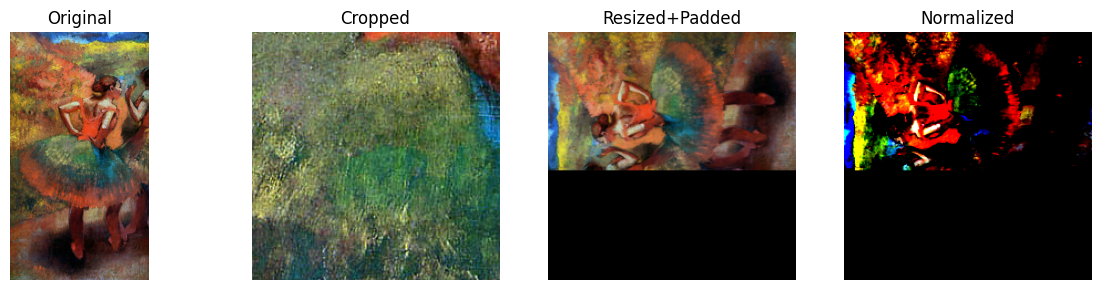

In [10]:
# Image Transformer Function

def image_transformer_nn(image, apply_norm=True, crop_img=True, new_dim=224):
    """
    Args:
        image: PIL Image object
        apply_norm (bool): Apply ImageNet normalization
        crop_img (bool): Crop center square vs resize with padding
        new_dim (int): Target dimension (224 for ResNet)
    """
    if crop_img:
        cropper = transforms.CenterCrop(new_dim)
        image = cropper(image)
    
    tensoring = transforms.ToTensor()
    image = tensoring(image)
    channels, height, width = image.shape
    
    # Handle grayscale images
    if image.shape[0] < 3:
        image = image.expand(3, -1, -1)
    # Handle extra channels
    if image.shape[0] > 3:
        image = image[0:3, :, :]
    
    # ImageNet normalization
    if apply_norm:
        normalizer = transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        image = normalizer(image)
    
    if not crop_img:
        if width < height:
            image = image.transpose(1, 2)
        channels, height, width = image.shape
        res_percent = float(new_dim / width)
        height = round(height * res_percent)
        resizer = transforms.Resize((height, new_dim))
        image = resizer(image)
        padder = transforms.Pad([0, 0, 0, int(new_dim - height)])
        image = padder(image)
    
    return image

# Example usage with extracted files
train_images_path = '/kaggle/working/train_top24/'
test_images_path = '/kaggle/working/test_top24/'

# Get a sample image file
sample_files = [f for f in os.listdir(train_images_path) if f.endswith('.jpg')]
if sample_files:
    sample_file = sample_files[0]
    image = Image.open(os.path.join(train_images_path, sample_file))
    
    print("Original image:")
    plt.figure(figsize=(12, 3))
    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis('off')
    
    print("Cropped transformed image:")
    image2 = image_transformer_nn(image, apply_norm=False, crop_img=True, new_dim=224)
    plt.subplot(1, 4, 2)
    plt.imshow(image2.numpy().transpose(1, 2, 0))
    plt.title("Cropped")
    plt.axis('off')
    
    print("Resized with padding:")
    image3a = image_transformer_nn(image, apply_norm=False, crop_img=False, new_dim=224)
    plt.subplot(1, 4, 3)
    plt.imshow(image3a.numpy().transpose(1, 2, 0))
    plt.title("Resized+Padded")
    plt.axis('off')
    
    print("Resized with normalization:")
    image3b = image_transformer_nn(image, apply_norm=True, crop_img=False, new_dim=224)
    plt.subplot(1, 4, 4)
    plt.imshow(image3b.numpy().transpose(1, 2, 0))
    plt.title("Normalized")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [11]:
# ImageDataset Class for Neural Networks

class ImageDataset(Dataset):
    def __init__(self, dataframe, lab_encoder, img_size=224, normalize=True, crop=False):
        """
        Args:
            dataframe (pd.DataFrame): Dataframe with image info
            lab_encoder: Label encoder for artist names
            img_size (int): Image dimension (default 224)
            normalize (bool): Apply ImageNet normalization
            crop (bool): True=crop center, False=resize with padding
        """
        self.encoder = lab_encoder
        self.img_size = img_size
        self.normalize = normalize
        self.crop = crop
        self.train_path = '/kaggle/working/train_top24/'
        self.test_path = '/kaggle/working/test_top24/'
        self.feats, self.labels = self.get_all_items(dataframe)
    
    def get_all_items(self, dataframe):
        feats = []
        labels = []
        
        for index, row in dataframe.iterrows():
            filename = row['new_filename']
            
            # Determine if image is in train or test
            if row['in_train']:
                img_path = os.path.join(self.train_path, filename)
            else:
                img_path = os.path.join(self.test_path, filename)
            
            try:
                # Load image from extracted files
                image = Image.open(img_path)
                datum = image_transformer_nn(image, apply_norm=self.normalize,
                                            crop_img=self.crop, new_dim=self.img_size)
                feats.append(datum)
                
                # Label
                artist = row['artist']
                label = self.encoder.transform([artist])[0]
                labels.append(label)
            except Exception as e:
                print(f"Error loading {filename}: {e}")
        
        feats = torch.stack(feats)
        labels = torch.LongTensor(labels)
        return feats, labels
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, item):
        return self.feats[item], self.labels[item]

In [13]:
# Data Splitter Function

def DataSplitter(data, ratios=[60, 20, 20], need_val=True, batches=None, shuffle=True, seed=42):
    """
    Split data into train/val/test sets
    
    Args:
        data: ImageDataset or tuple (X, y)
        ratios: [train%, val%, test%]
        need_val: Whether to create validation set
        batches: Batch size for DataLoaders (NN case)
        shuffle: Shuffle data
        seed: Random seed
    """
    first_ratio = (ratios[1] + ratios[2]) / sum(ratios)
    second_ratio = ratios[2] / (ratios[1] + ratios[2])
    
    if isinstance(data, ImageDataset):  # Neural Network case
        labels = data.labels.numpy()
        
        train_indices, rest_indices = train_test_split(
            np.arange(len(labels)),
            test_size=first_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=labels
        )
        
        rest_labels = data[rest_indices][1]
        
        val_indices, test_indices = train_test_split(
            rest_indices,
            test_size=second_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=rest_labels
        )
        
        train_sampler = SubsetRandomSampler(train_indices)
        val_sampler = SubsetRandomSampler(val_indices)
        test_sampler = SubsetRandomSampler(test_indices)
        
        train_loader = DataLoader(data, batch_size=batches, sampler=train_sampler)
        val_loader = DataLoader(data, batch_size=batches, sampler=val_sampler)
        test_loader = DataLoader(data, batch_size=batches, sampler=test_sampler)
        
        return train_loader, val_loader, test_loader
    
    elif isinstance(data, tuple):  # SVM/other models case
        X_train, X_rest, y_train, y_rest = train_test_split(
            data[0], data[1],
            test_size=first_ratio,
            shuffle=shuffle,
            random_state=seed,
            stratify=data[1]
        )
        
        if need_val:
            X_val, X_test, y_val, y_test = train_test_split(
                X_rest, y_rest,
                test_size=second_ratio,
                shuffle=shuffle,
                random_state=seed,
                stratify=y_rest
            )
            return X_train, X_val, X_test, y_train, y_val, y_test
        
        return X_train, X_rest, y_train, y_rest
    
    else:
        print('Invalid data type. Use ImageDataset or tuple (X, y).')
        return

In [14]:
# Visualization Functions

sns.set(style="darkgrid")

def CustomCmap(from_rgb, to_rgb):
    """Create custom colormap"""
    r1, g1, b1 = from_rgb
    r2, g2, b2 = to_rgb
    cdict = {
        'red': ((0, r1, r1), (1, r2, r2)),
        'green': ((0, g1, g1), (1, g2, g2)),
        'blue': ((0, b1, b1), (1, b2, b2))
    }
    cmap = LinearSegmentedColormap('custom_cmap', cdict)
    return cmap

mycmap = CustomCmap([1.0, 1.0, 1.0], [72/255, 99/255, 147/255])
mycmap_r = CustomCmap([72/255, 99/255, 147/255], [1.0, 1.0, 1.0])
mycol = (72/255, 99/255, 147/255)
mycomplcol = (129/255, 143/255, 163/255)

def plot_cm(cfmatrix, title, classes):
    """Plot confusion matrix"""
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 10))
    
    im = ax1.imshow(cfmatrix, interpolation='nearest', cmap=mycmap)
    divider = make_axes_locatable(ax1)
    cax = divider.append_axes("right", size="5%", pad=0.2)
    plt.colorbar(im, cax=cax)
    
    ax1.set_title(title, fontsize=14)
    tick_marks = np.arange(len(classes))
    ax1.set_xticks(tick_marks)
    ax1.set_xticklabels(classes, rotation=90)
    ax1.set_yticks(tick_marks)
    ax1.set_yticklabels(classes)
    
    fmt = 'd'
    thresh = cfmatrix.max() / 2.
    for i, j in itertools.product(range(cfmatrix.shape[0]), range(cfmatrix.shape[1])):
        ax1.text(j, i, format(cfmatrix[i, j], fmt),
                horizontalalignment="center",
                color="white" if cfmatrix[i, j] > thresh else "black")
    
    ax1.set_ylabel('True label', fontsize=14)
    ax1.set_xlabel('Predicted label', fontsize=14)
    plt.savefig(title + '.pdf', bbox_inches='tight')
    plt.show()

print("All blocks loaded successfully!")
print(f"Ready to proceed to Part B with {N} artists and {len(active_df)} images!")

All blocks loaded successfully!
Ready to proceed to Part B with 24 artists and 11880 images!


# PART B: CNN Model

In [17]:
%%time
# Load the Dataset for NN training
nn_data = ImageDataset(active_df, LabEnc, img_size=224, normalize=True, crop=False)
print(f"✅ Dataset loaded with {len(nn_data)} images")
print(f"   Image shape: {nn_data[0][0].shape}")
print(f"   Number of classes: {len(artists)}")

Error loading 81823.jpg: Image size (669000000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
✅ Dataset loaded with 11879 images
   Image shape: torch.Size([3, 224, 224])
   Number of classes: 24
CPU times: user 14min 24s, sys: 3min 34s, total: 17min 59s
Wall time: 9min 49s


In [18]:
# Create Data Loaders with Optimal Batch Size
# Larger batch size for better GPU utilization and stable gradients
BATCH_SIZE = 64  

train_loader, val_loader, test_loader = DataSplitter(
    nn_data, 
    ratios=[60, 25, 15], 
    need_val=True, 
    batches=BATCH_SIZE, 
    shuffle=True, 
    seed=42  # Changed to 42 for consistency
)

# Verify splits
print(f"\n📊 Data Split Information:")
print(f"   Training batches: {len(train_loader)} (samples: {len(train_loader)*BATCH_SIZE})")
print(f"   Validation batches: {len(val_loader)} (samples: {len(val_loader)*BATCH_SIZE})")
print(f"   Test batches: {len(test_loader)} (samples: {len(test_loader)*BATCH_SIZE})")


📊 Data Split Information:
   Training batches: 112 (samples: 7168)
   Validation batches: 47 (samples: 3008)
   Test batches: 28 (samples: 1792)


In [93]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## CNN Experiments

In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import json
from datetime import datetime

# ============================================================================
# ENHANCED CHECKPOINT SYSTEM FOR RESUMABLE TRAINING
# ============================================================================

class ResumableTrainer:
    """Handles resumable training with epoch batching"""
    
    def __init__(self, model_name, checkpoint_dir=None):
        self.model_name = model_name
        
        # Auto-detect Kaggle environment
        if checkpoint_dir is None:
            if os.path.exists('/kaggle/working'):
                # Kaggle environment - save to working dir (becomes output)
                checkpoint_dir = '/kaggle/working/checkpoints'
                print(f"🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/")
            else:
                # Local environment
                checkpoint_dir = './checkpoints'
        
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        self.state_file = os.path.join(checkpoint_dir, f'{model_name}_training_state.json')
        self.model_file = os.path.join(checkpoint_dir, f'{model_name}_model.pt')
        self.best_model_file = os.path.join(checkpoint_dir, f'{model_name}_best.pt')
        
    def save_training_state(self, epoch, train_losses, val_losses, train_accs, 
                           val_accs, best_val_acc, optimizer_state, scheduler_state,
                           early_stopping_counter, best_score, val_loss_min):
        """Save complete training state"""
        state = {
            'epoch': epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc,
            'optimizer_state': optimizer_state,
            'scheduler_state': scheduler_state,
            'early_stopping': {
                'counter': early_stopping_counter,
                'best_score': best_score,
                'val_loss_min': val_loss_min
            },
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        with open(self.state_file, 'w') as f:
            json.dump(state, f, indent=2)
        
        print(f"   💾 State saved at epoch {epoch}")
    
    def load_training_state(self):
        """Load training state if exists"""
        if os.path.exists(self.state_file):
            with open(self.state_file, 'r') as f:
                state = json.load(f)
            print(f"   📂 Loaded state from epoch {state['epoch']}")
            return state
        return None
    
    def save_model(self, model, optimizer, scheduler=None):
        """Save model and optimizer"""
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None
        }, self.model_file)
    
    def load_model(self, model, optimizer, scheduler=None):
        """Load model and optimizer"""
        if os.path.exists(self.model_file):
            checkpoint = torch.load(self.model_file)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if scheduler and checkpoint['scheduler_state_dict']:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            print(f"   ✅ Model loaded from checkpoint")
            return True
        return False


# ============================================================================
# MODIFIED TRAINING FUNCTION WITH EPOCH BATCHING
# ============================================================================

def train_model_resumable(model, train_loader, val_loader, optimizer, scheduler, 
                         total_epochs, loss_fn, device, patience, model_name, 
                         epochs_per_batch=10, verbose_ct=1, resume=True):
    """
    Train model with resumable epoch batching.
    
    Args:
        epochs_per_batch: Number of epochs to run per batch (default: 10)
        resume: Whether to resume from checkpoint (default: True)
    """
    
    trainer = ResumableTrainer(model_name)
    
    # Initialize training state
    start_epoch = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    es_counter = 0
    es_best_score = None
    es_val_loss_min = np.Inf
    
    # Try to resume from checkpoint
    if resume:
        state = trainer.load_training_state()
        if state:
            start_epoch = state['epoch'] + 1
            train_losses = state['train_losses']
            val_losses = state['val_losses']
            train_accs = state['train_accs']
            val_accs = state['val_accs']
            best_val_acc = state['best_val_acc']
            es_counter = state['early_stopping']['counter']
            es_best_score = state['early_stopping']['best_score']
            es_val_loss_min = state['early_stopping']['val_loss_min']
            
            # Load model and optimizer
            trainer.load_model(model, optimizer, scheduler)
            
            print(f"\n🔄 RESUMING from epoch {start_epoch}")
            print(f"   Best Val Acc so far: {best_val_acc:.2f}%")
            print(f"   Early stopping counter: {es_counter}/{patience}")
    
    # Calculate which batch we're in
    current_batch = start_epoch // epochs_per_batch + 1
    batch_start = start_epoch
    batch_end = min(start_epoch + epochs_per_batch, total_epochs)
    
    print(f"\n🚀 Training: {model_name}")
    print(f"📦 BATCH {current_batch}: Epochs {batch_start+1} to {batch_end}")
    print("="*70)
    
    # Training loop for current batch
    for epoch in range(batch_start, batch_end):
        # Training
        train_loss, train_acc = training_loop(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validation_loop(model, val_loader, loss_fn, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Learning rate scheduling
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Early stopping logic
        score = -val_loss
        if es_best_score is None:
            es_best_score = score
            es_val_loss_min = val_loss
            trainer.save_model(model, optimizer, scheduler)
            torch.save(model.state_dict(), trainer.best_model_file)
        elif score < es_best_score + 0.001:
            es_counter += 1
            if verbose_ct > 0:
                print(f'   ⚠️  EarlyStopping: {es_counter}/{patience}')
        else:
            if val_loss < es_val_loss_min:
                print(f'   ✅ Val loss: {es_val_loss_min:.4f} → {val_loss:.4f}')
            es_best_score = score
            es_val_loss_min = val_loss
            es_counter = 0
            trainer.save_model(model, optimizer, scheduler)
        
        # Track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), trainer.best_model_file)
        
        # Print progress
        if epoch % verbose_ct == 0 or epoch == batch_end - 1:
            print(f"Epoch {epoch+1:3d}/{total_epochs} | "
                  f"TL: {train_loss:.4f} TA: {train_acc:.2f}% | "
                  f"VL: {val_loss:.4f} VA: {val_acc:.2f}%")
        
        # Save state after each epoch (for resumability)
        trainer.save_training_state(
            epoch, train_losses, val_losses, train_accs, val_accs,
            best_val_acc, optimizer.state_dict(), 
            scheduler.state_dict() if scheduler else None,
            es_counter, es_best_score, es_val_loss_min
        )
        
        # Check early stopping
        if es_counter >= patience:
            print(f"\n🛑 Early stop at epoch {epoch+1}")
            model.load_state_dict(torch.load(trainer.best_model_file))
            break
    
    print(f"\n✅ Batch {current_batch} complete!")
    print(f"✅ Best Val Acc: {best_val_acc:.2f}%")
    
    if batch_end < total_epochs and es_counter < patience:
        print(f"\n⏭️  To continue training, run this cell again!")
        print(f"   Next batch: Epochs {batch_end+1} to {min(batch_end + epochs_per_batch, total_epochs)}")
    else:
        print(f"\n🎉 Training complete or early stopped!")
    
    return train_losses, val_losses, train_accs, val_accs, best_val_acc


# ============================================================================
# HELPER FUNCTION TO CHECK TRAINING STATUS
# ============================================================================

def check_training_status(model_name, checkpoint_dir='checkpoints'):
    """Check the current training status"""
    state_file = os.path.join(checkpoint_dir, f'{model_name}_training_state.json')
    
    if not os.path.exists(state_file):
        print(f"❌ No checkpoint found for {model_name}")
        return None
    
    with open(state_file, 'r') as f:
        state = json.load(f)
    
    print(f"\n📊 Training Status: {model_name}")
    print("="*70)
    print(f"Current Epoch: {state['epoch'] + 1}")
    print(f"Best Val Acc: {state['best_val_acc']:.2f}%")
    print(f"Latest Train Acc: {state['train_accs'][-1]:.2f}%")
    print(f"Latest Val Acc: {state['val_accs'][-1]:.2f}%")
    print(f"Early Stopping Counter: {state['early_stopping']['counter']}")
    print(f"Last Updated: {state['timestamp']}")
    print("="*70)
    
    return state


# ============================================================================
# USAGE EXAMPLE
# ============================================================================



In [30]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Track all experiments
experiment_results = {}

def save_experiment_result(name, metrics):
    """Save experiment results for comparison"""
    experiment_results[name] = metrics
    print(f"✅ Results saved for: {name}")

def compare_all_experiments():
    """Compare all experiments at the end"""
    print("\n" + "="*80)
    print("EXPERIMENT COMPARISON")
    print("="*80)
    print(f"{'Experiment':<35} {'Best Val Acc':<15} {'Test Acc':<15}")
    print("-"*80)
    for name, metrics in experiment_results.items():
        print(f"{name:<35} {metrics['best_val_acc']:>12.2f}%   {metrics['test_acc']:>12.2f}%")
    print("="*80)


# ============================================================================
# PART 2: FLEXIBLE CNN ARCHITECTURE BUILDER
# This creates CNNs with different activation functions and pooling types
# ============================================================================

class FlexibleCNN(nn.Module):
    """
    Flexible CNN that supports:
    - Different activation functions (ReLU, LeakyReLU, ELU, GELU)
    - Different pooling types (MaxPool, AvgPool)
    - Different number of blocks (3, 4, or 5)
    """
    def __init__(self, num_classes, activation='relu', pooling='max', 
                 num_blocks=4, dropout=0.5, channels=[64, 128, 256, 512, 512]):
        super(FlexibleCNN, self).__init__()
        
        self.num_blocks = num_blocks
        self.activation_name = activation
        self.pooling_name = pooling
        
        # Choose activation function
        activation_dict = {
            'relu': nn.ReLU(inplace=True),
            'leakyrelu': nn.LeakyReLU(0.1, inplace=True),
            'elu': nn.ELU(inplace=True),
            'gelu': nn.GELU(),
            'prelu': nn.PReLU()
        }
        self.activation = activation_dict.get(activation.lower(), nn.ReLU(inplace=True))
        
        # Choose pooling function
        if pooling.lower() == 'max':
            self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        else:  # avg
            self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        
        # Build convolutional blocks
        layers = []
        in_channels = 3
        
        for i in range(num_blocks):
            out_channels = channels[i]
            
            # First conv in block
            layers.extend([
                nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(out_channels),
                self._get_activation()
            ])
            
            # Second conv in block
            layers.extend([
                nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                nn.BatchNorm2d(out_channels),
                self._get_activation(),
                self._get_pooling()
            ])
            
            in_channels = out_channels
        
        self.features = nn.Sequential(*layers)
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        
        # Classifier
        final_channels = channels[num_blocks-1]
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(final_channels, 256),
            self._get_activation(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    
    def _get_activation(self):
        """Return a new instance of activation"""
        activation_dict = {
            'relu': nn.ReLU(inplace=True),
            'leakyrelu': nn.LeakyReLU(0.1, inplace=True),
            'elu': nn.ELU(inplace=True),
            'gelu': nn.GELU(),
            'prelu': nn.PReLU()
        }
        return activation_dict.get(self.activation_name.lower(), nn.ReLU(inplace=True))
    
    def _get_pooling(self):
        """Return pooling layer"""
        if self.pooling_name.lower() == 'max':
            return nn.MaxPool2d(kernel_size=2, stride=2)
        else:
            return nn.AvgPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# ============================================================================
# PART 3: TRAINING INFRASTRUCTURE (Same as before)
# ============================================================================

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    
    def forward(self, pred, target):
        n_class = pred.size(1)
        one_hot = torch.zeros_like(pred).scatter(1, target.unsqueeze(1), 1)
        one_hot = one_hot * (1 - self.smoothing) + self.smoothing / n_class
        log_prob = F.log_softmax(pred, dim=1)
        loss = -(one_hot * log_prob).sum(dim=1).mean()
        return loss


def training_loop(model, train_loader, optimizer, loss_fn, device):
    model.train()
    batch_losses = []
    correct = 0
    total = 0
    
    for batch in train_loader:
        x_batch, y_batch = batch
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        yhat = model(x_batch)
        loss = loss_fn(yhat, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        batch_losses.append(loss.item())
        _, predicted = torch.max(yhat.data, 1)
        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()
    
    return np.mean(batch_losses), 100 * correct / total


def validation_loop(model, val_loader, loss_fn, device):
    model.eval()
    batch_losses = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in val_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            yhat = model(x_batch)
            loss = loss_fn(yhat, y_batch)
            
            batch_losses.append(loss.item())
            _, predicted = torch.max(yhat.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    
    return np.mean(batch_losses), 100 * correct / total


class EarlyStopping:
    def __init__(self, patience=10, verbose=True, delta=0.001, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
    
    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'   ⚠️  EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
    
    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'   ✅ Val loss: {self.val_loss_min:.4f} → {val_loss:.4f}. Saving...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


def train_model(model, train_loader, val_loader, optimizer, scheduler, epochs, 
                loss_fn, device, patience, model_name, verbose_ct=1):
    """Unified training function"""
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    
    checkpoint_path = f'checkpoint_{model_name}.pt'
    final_path = f'{model_name}_final.pt'
    
    early_stopping = EarlyStopping(patience=patience, verbose=True, path=checkpoint_path)
    best_val_acc = 0
    
    print(f"\n🚀 Training: {model_name}")
    print("="*70)
    
    for epoch in range(epochs):
        train_loss, train_acc = training_loop(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validation_loop(model, val_loader, loss_fn, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        if scheduler is not None:
            scheduler.step(val_loss)
        
        early_stopping(val_loss, model)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), final_path)
        
        if epoch % verbose_ct == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch+1:3d}/{epochs} | "
                  f"TL: {train_loss:.4f} TA: {train_acc:.2f}% | "
                  f"VL: {val_loss:.4f} VA: {val_acc:.2f}%")
        
        if early_stopping.early_stop:
            print(f"\n🛑 Early stop at epoch {epoch+1}")
            model.load_state_dict(torch.load(checkpoint_path))
            break
    
    print(f"✅ Best Val Acc: {best_val_acc:.2f}%")
    return train_losses, val_losses, train_accs, val_accs, best_val_acc


def evaluate_model(model, test_loader, device):
    """Evaluate model on test set"""
    model.eval()
    predictions = []
    labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            x_batch, y_batch = batch
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            
            yhat = model(x_batch)
            yhat_idx = torch.argmax(yhat, dim=1)
            
            predictions.append(yhat_idx.cpu().numpy())
            labels.append(y_batch.cpu().numpy())
    
    y_pred = np.concatenate(predictions, axis=0)
    y_true = np.concatenate(labels, axis=0)
    accuracy = 100 * np.sum(y_pred == y_true) / len(y_true)
    
    return y_pred, y_true, accuracy


print("✅ Setup complete! Ready to run experiments.")

Using device: cuda
✅ Setup complete! Ready to run experiments.


In [31]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import os
import json
from datetime import datetime

# ============================================================================
# ENHANCED CHECKPOINT SYSTEM FOR RESUMABLE TRAINING
# ============================================================================

class ResumableTrainer:
    """Handles resumable training with epoch batching"""
    
    def __init__(self, model_name, checkpoint_dir=None):
        self.model_name = model_name
        
        # Auto-detect Kaggle environment
        if checkpoint_dir is None:
            if os.path.exists('/kaggle/working'):
                # Kaggle environment - save to working dir (becomes output)
                checkpoint_dir = '/kaggle/working/checkpoints'
                print(f"🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/")
            else:
                # Local environment
                checkpoint_dir = './checkpoints'
        
        self.checkpoint_dir = checkpoint_dir
        os.makedirs(checkpoint_dir, exist_ok=True)
        
        self.state_file = os.path.join(checkpoint_dir, f'{model_name}_training_state.json')
        self.model_file = os.path.join(checkpoint_dir, f'{model_name}_model.pt')
        self.best_model_file = os.path.join(checkpoint_dir, f'{model_name}_best.pt')
        
    def save_training_state(self, epoch, train_losses, val_losses, train_accs, 
                           val_accs, best_val_acc, early_stopping_counter, 
                           best_score, val_loss_min):
        """Save complete training state (JSON only, no optimizer/scheduler)"""
        state = {
            'epoch': epoch,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'train_accs': train_accs,
            'val_accs': val_accs,
            'best_val_acc': best_val_acc,
            'early_stopping': {
                'counter': early_stopping_counter,
                'best_score': best_score,
                'val_loss_min': val_loss_min
            },
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        with open(self.state_file, 'w') as f:
            json.dump(state, f, indent=2)
        
        print(f"   💾 State saved at epoch {epoch}")
    
    def load_training_state(self):
        """Load training state if exists"""
        if os.path.exists(self.state_file):
            with open(self.state_file, 'r') as f:
                state = json.load(f)
            print(f"   📂 Loaded state from epoch {state['epoch']}")
            return state
        return None
    
    def save_model(self, model, optimizer, scheduler=None, epoch=None):
        """Save model, optimizer, and scheduler states"""
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
            'epoch': epoch
        }
        torch.save(checkpoint, self.model_file)
    
    def load_model(self, model, optimizer, scheduler=None):
        """Load model and optimizer"""
        if os.path.exists(self.model_file):
            checkpoint = torch.load(self.model_file)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            if scheduler and checkpoint['scheduler_state_dict']:
                scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            print(f"   ✅ Model loaded from checkpoint")
            return True
        return False


# ============================================================================
# MODIFIED TRAINING FUNCTION WITH EPOCH BATCHING
# ============================================================================

def train_model_resumable(model, train_loader, val_loader, optimizer, scheduler, 
                         total_epochs, loss_fn, device, patience, model_name, 
                         epochs_per_batch=10, verbose_ct=1, resume=True):
    """
    Train model with resumable epoch batching.
    
    Args:
        epochs_per_batch: Number of epochs to run per batch (default: 10)
        resume: Whether to resume from checkpoint (default: True)
    """
    
    trainer = ResumableTrainer(model_name)
    
    # Initialize training state
    start_epoch = 0
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0
    es_counter = 0
    es_best_score = None
    es_val_loss_min = np.Inf
    
    # Try to resume from checkpoint
    if resume:
        state = trainer.load_training_state()
        if state:
            start_epoch = state['epoch'] + 1
            train_losses = state['train_losses']
            val_losses = state['val_losses']
            train_accs = state['train_accs']
            val_accs = state['val_accs']
            best_val_acc = state['best_val_acc']
            es_counter = state['early_stopping']['counter']
            es_best_score = state['early_stopping']['best_score']
            es_val_loss_min = state['early_stopping']['val_loss_min']
            
            # Load model and optimizer
            trainer.load_model(model, optimizer, scheduler)
            
            print(f"\n🔄 RESUMING from epoch {start_epoch}")
            print(f"   Best Val Acc so far: {best_val_acc:.2f}%")
            print(f"   Early stopping counter: {es_counter}/{patience}")
    
    # Calculate which batch we're in
    current_batch = start_epoch // epochs_per_batch + 1
    batch_start = start_epoch
    batch_end = min(start_epoch + epochs_per_batch, total_epochs)
    
    print(f"\n🚀 Training: {model_name}")
    print(f"📦 BATCH {current_batch}: Epochs {batch_start+1} to {batch_end}")
    print("="*70)
    
    # Training loop for current batch
    for epoch in range(batch_start, batch_end):
        # Training
        train_loss, train_acc = training_loop(model, train_loader, optimizer, loss_fn, device)
        val_loss, val_acc = validation_loop(model, val_loader, loss_fn, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Learning rate scheduling
        if scheduler is not None:
            scheduler.step(val_loss)
        
        # Early stopping logic
        score = -val_loss
        if es_best_score is None:
            es_best_score = score
            es_val_loss_min = val_loss
            trainer.save_model(model, optimizer, scheduler, epoch)
            torch.save(model.state_dict(), trainer.best_model_file)
        elif score < es_best_score + 0.001:
            es_counter += 1
            if verbose_ct > 0:
                print(f'   ⚠️  EarlyStopping: {es_counter}/{patience}')
        else:
            if val_loss < es_val_loss_min:
                print(f'   ✅ Val loss: {es_val_loss_min:.4f} → {val_loss:.4f}')
            es_best_score = score
            es_val_loss_min = val_loss
            es_counter = 0
            trainer.save_model(model, optimizer, scheduler, epoch)
        
        # Track best validation accuracy
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), trainer.best_model_file)
        
        # Print progress
        if epoch % verbose_ct == 0 or epoch == batch_end - 1:
            print(f"Epoch {epoch+1:3d}/{total_epochs} | "
                  f"TL: {train_loss:.4f} TA: {train_acc:.2f}% | "
                  f"VL: {val_loss:.4f} VA: {val_acc:.2f}%")
        
        # Save state after each epoch (for resumability)
        trainer.save_training_state(
            epoch, train_losses, val_losses, train_accs, val_accs,
            best_val_acc, es_counter, es_best_score, es_val_loss_min
        )
        
        # Check early stopping
        if es_counter >= patience:
            print(f"\n🛑 Early stop at epoch {epoch+1}")
            model.load_state_dict(torch.load(trainer.best_model_file))
            break
    
    print(f"\n✅ Batch {current_batch} complete!")
    print(f"✅ Best Val Acc: {best_val_acc:.2f}%")
    
    if batch_end < total_epochs and es_counter < patience:
        print(f"\n⏭️  To continue training, run this cell again!")
        print(f"   Next batch: Epochs {batch_end+1} to {min(batch_end + epochs_per_batch, total_epochs)}")
    else:
        print(f"\n🎉 Training complete or early stopped!")
    
    return train_losses, val_losses, train_accs, val_accs, best_val_acc


# ============================================================================
# HELPER FUNCTION TO CHECK TRAINING STATUS
# ============================================================================

def check_training_status(model_name, checkpoint_dir='checkpoints'):
    """Check the current training status"""
    state_file = os.path.join(checkpoint_dir, f'{model_name}_training_state.json')
    
    if not os.path.exists(state_file):
        print(f"❌ No checkpoint found for {model_name}")
        return None
    
    with open(state_file, 'r') as f:
        state = json.load(f)
    
    print(f"\n📊 Training Status: {model_name}")
    print("="*70)
    print(f"Current Epoch: {state['epoch'] + 1}")
    print(f"Best Val Acc: {state['best_val_acc']:.2f}%")
    print(f"Latest Train Acc: {state['train_accs'][-1]:.2f}%")
    print(f"Latest Val Acc: {state['val_accs'][-1]:.2f}%")
    print(f"Early Stopping Counter: {state['early_stopping']['counter']}")
    print(f"Last Updated: {state['timestamp']}")
    print("="*70)
    
    return state

In [36]:
%%time
exp_name = "Exp1_ReLU_MaxPool_4Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='relu',
    pooling='max',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

# ✨ CHANGED: train_model → train_model_resumable
t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=50,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)

# Evaluation (load best model first)
best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'ReLU, MaxPool, 4 blocks'
})


Exp1_ReLU_MaxPool_4Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 39
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 40
   Best Val Acc so far: 62.36%
   Early stopping counter: 1/15

🚀 Training: Exp1_ReLU_MaxPool_4Blocks
📦 BATCH 5: Epochs 41 to 50
   ⚠️  EarlyStopping: 2/15
Epoch  41/50 | TL: 1.6619 TA: 63.14% | VL: 1.6932 VA: 61.92%
   💾 State saved at epoch 40
   ⚠️  EarlyStopping: 3/15
Epoch  42/50 | TL: 1.6399 TA: 64.18% | VL: 1.8236 VA: 57.31%
   💾 State saved at epoch 41
   ⚠️  EarlyStopping: 4/15
Epoch  43/50 | TL: 1.6382 TA: 64.37% | VL: 1.6834 VA: 62.19%
   💾 State saved at epoch 42
   ⚠️  EarlyStopping: 5/15
Epoch  44/50 | TL: 1.6165 TA: 64.95% | VL: 1.7289 VA: 61.41%
   💾 State saved at epoch 43
   ⚠️  EarlyStopping: 6/15
Epoch  45/50 | TL: 1.6065 TA: 65.48% | VL: 1.6838 VA: 62.32%
   💾 State saved at epoch 44
   ⚠️  EarlyStopping: 7/15
Epoch  46/50 | TL: 1.6072 TA: 65.19% | VL: 1.7393 VA: 60.37%
   💾 State saved at e

✅ Loaded best model from: /kaggle/working/checkpoints/Exp1_ReLU_MaxPool_4Blocks_best.pt
🎯 Test Accuracy: 66.16%

📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.63      0.65      0.64        74
                 Rembrandt       0.68      0.36      0.47        74
             Ivan Shishkin       0.69      0.47      0.56        74
              Gustave Dore       0.63      0.81      0.71        74
             Pablo Picasso       0.42      0.61      0.50        74
     Pierre-Auguste Renoir       0.80      0.86      0.83        74
         Zdislav Beksinski       0.96      0.96      0.96        75
                Ilya Repin       0.90      0.92      0.91        75
              Marc Chagall       0.52      0.50      0.51        74
           Ivan Aivazovsky       0.65      0.46      0.54        74
            Albrecht Durer       0.75      0.85      0.80        75
       John Singer Sargent       0.74      0.7

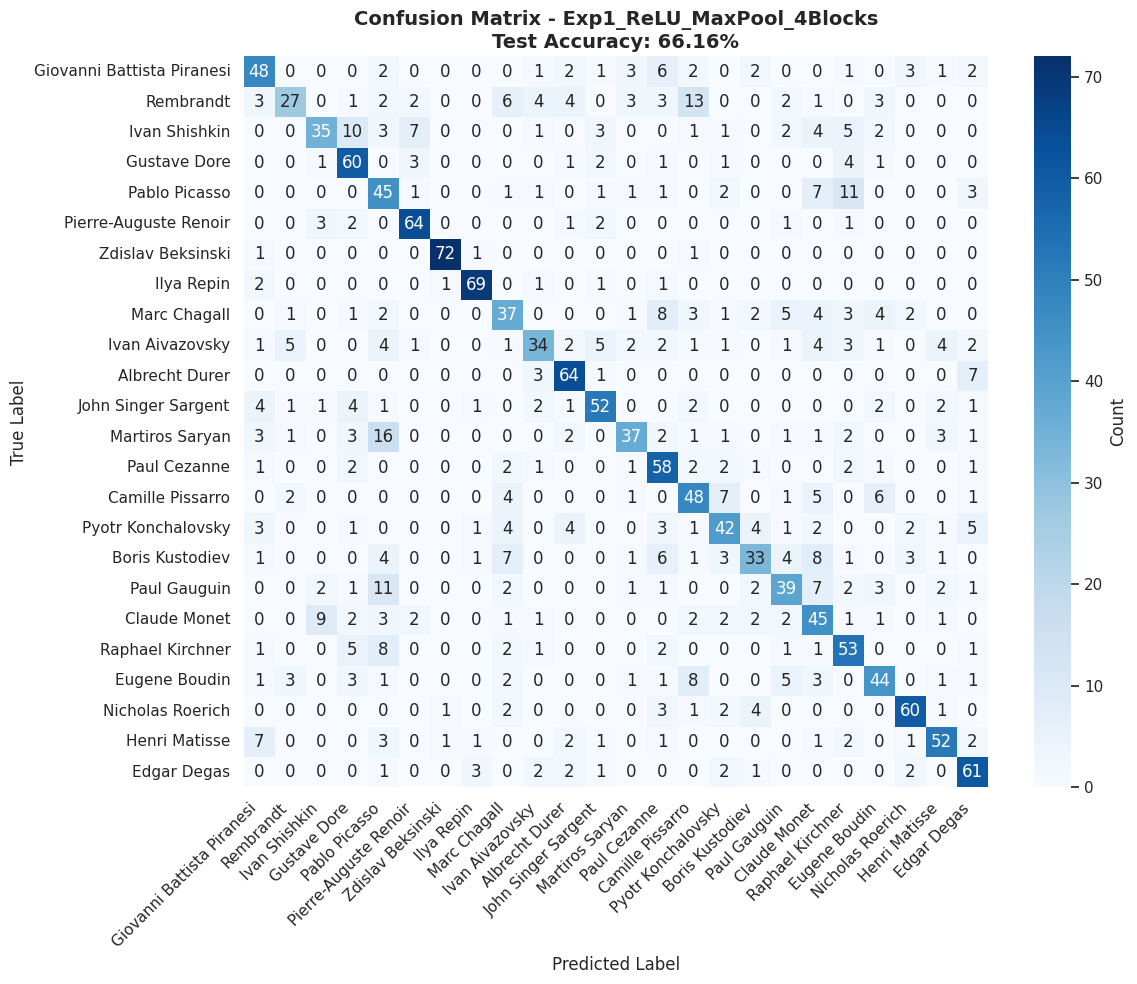

✅ Results saved for: Exp1_ReLU_MaxPool_4Blocks

✅ Evaluation complete!


In [41]:
# ============================================================================
# EVALUATION AFTER TRAINING COMPLETES
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Load the best model from checkpoints
exp_name = "Exp1_ReLU_MaxPool_4Blocks"  # Use your experiment name

# Recreate the model architecture (must match training)
model = FlexibleCNN(
    num_classes=len(artists),
    activation='relu',
    pooling='max',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

# Load best weights
best_model_path = f'/kaggle/working/checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))
print(f"✅ Loaded best model from: {best_model_path}")

# Evaluate on test set
preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save results
save_experiment_result(exp_name, {
    'best_val_acc': best_val,  # From training
    'test_acc': test_acc,
    'config': 'ReLU, MaxPool, 4 blocks'
})

print("\n✅ Evaluation complete!")

In [48]:
%%time
exp_name = "exp2_LeakyReLU_MaxPool_4Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='leakyrelu',
    pooling='max',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

# ✨ CHANGED: train_model → train_model_resumable
t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=60,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)

# Evaluation (load best model first)
best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'LeakyReLU, MaxPool, 4 blocks'
})


exp2_LeakyReLU_MaxPool_4Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 49
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 50
   Best Val Acc so far: 63.43%
   Early stopping counter: 3/15

🚀 Training: exp2_LeakyReLU_MaxPool_4Blocks
📦 BATCH 6: Epochs 51 to 60


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


   ⚠️  EarlyStopping: 4/15
Epoch  51/60 | TL: 1.5083 TA: 69.26% | VL: 1.7779 VA: 59.73%
   💾 State saved at epoch 50
   ⚠️  EarlyStopping: 5/15
Epoch  52/60 | TL: 1.5046 TA: 69.03% | VL: 1.8631 VA: 56.20%
   💾 State saved at epoch 51
   ⚠️  EarlyStopping: 6/15
Epoch  53/60 | TL: 1.4992 TA: 69.44% | VL: 1.6593 VA: 62.36%
   💾 State saved at epoch 52
   ✅ Val loss: 1.6491 → 1.6229
Epoch  54/60 | TL: 1.4771 TA: 70.66% | VL: 1.6229 VA: 64.98%
   💾 State saved at epoch 53
   ⚠️  EarlyStopping: 1/15
Epoch  55/60 | TL: 1.4617 TA: 71.29% | VL: 1.6379 VA: 64.44%
   💾 State saved at epoch 54
   ⚠️  EarlyStopping: 2/15
Epoch  56/60 | TL: 1.4402 TA: 72.54% | VL: 1.9404 VA: 54.81%
   💾 State saved at epoch 55
   ⚠️  EarlyStopping: 3/15
Epoch  57/60 | TL: 1.4319 TA: 72.74% | VL: 1.7120 VA: 62.39%
   💾 State saved at epoch 56
   ✅ Val loss: 1.6229 → 1.5775
Epoch  58/60 | TL: 1.4158 TA: 73.17% | VL: 1.5775 VA: 66.23%
   💾 State saved at epoch 57
   ⚠️  EarlyStopping: 1/15
Epoch  59/60 | TL: 1.4121 TA:


📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.53      0.74      0.62        74
                 Rembrandt       0.74      0.46      0.57        74
             Ivan Shishkin       0.70      0.61      0.65        74
              Gustave Dore       0.78      0.78      0.78        74
             Pablo Picasso       0.82      0.36      0.50        74
     Pierre-Auguste Renoir       0.79      0.82      0.81        74
         Zdislav Beksinski       0.95      0.95      0.95        75
                Ilya Repin       0.70      0.97      0.82        75
              Marc Chagall       0.55      0.57      0.56        74
           Ivan Aivazovsky       0.60      0.50      0.54        74
            Albrecht Durer       0.78      0.88      0.82        75
       John Singer Sargent       0.58      0.69      0.63        74
           Martiros Saryan       0.76      0.51      0.61        74
              Paul Cez

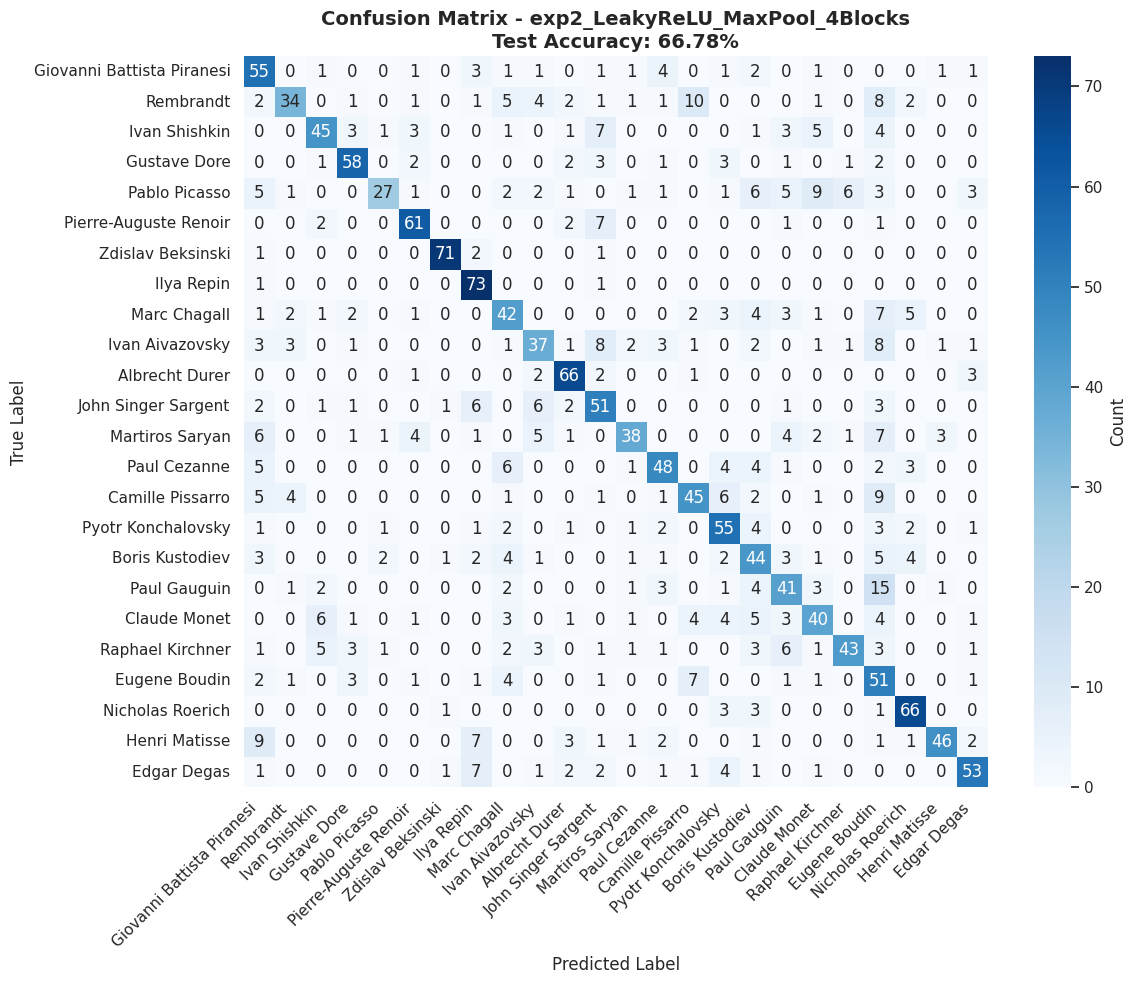

In [49]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
%%time
exp_name = "Exp3_ReLU_AvgPool_4Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='relu',
    pooling='avg',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=50,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)

best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'ReLU, AvgPool, 4 blocks'
})




Exp3_ReLU_AvgPool_4Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 49
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 50
   Best Val Acc so far: 55.82%
   Early stopping counter: 3/15

🚀 Training: Exp3_ReLU_AvgPool_4Blocks
📦 BATCH 6: Epochs 51 to 50

✅ Batch 6 complete!
✅ Best Val Acc: 55.82%

🎉 Training complete or early stopped!
🎯 Test Accuracy: 56.40%
✅ Results saved for: Exp3_ReLU_AvgPool_4Blocks
CPU times: user 4.45 s, sys: 26 ms, total: 4.48 s
Wall time: 3.93 s



📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.82      0.42      0.55        74
                 Rembrandt       0.44      0.49      0.46        74
             Ivan Shishkin       0.65      0.41      0.50        74
              Gustave Dore       0.57      0.70      0.63        74
             Pablo Picasso       0.32      0.42      0.36        74
     Pierre-Auguste Renoir       0.68      0.82      0.74        74
         Zdislav Beksinski       0.85      0.99      0.91        75
                Ilya Repin       0.86      0.92      0.89        75
              Marc Chagall       0.38      0.31      0.34        74
           Ivan Aivazovsky       0.50      0.45      0.47        74
            Albrecht Durer       0.70      0.77      0.73        75
       John Singer Sargent       0.78      0.58      0.67        74
           Martiros Saryan       0.35      0.66      0.46        74
              Paul Cez

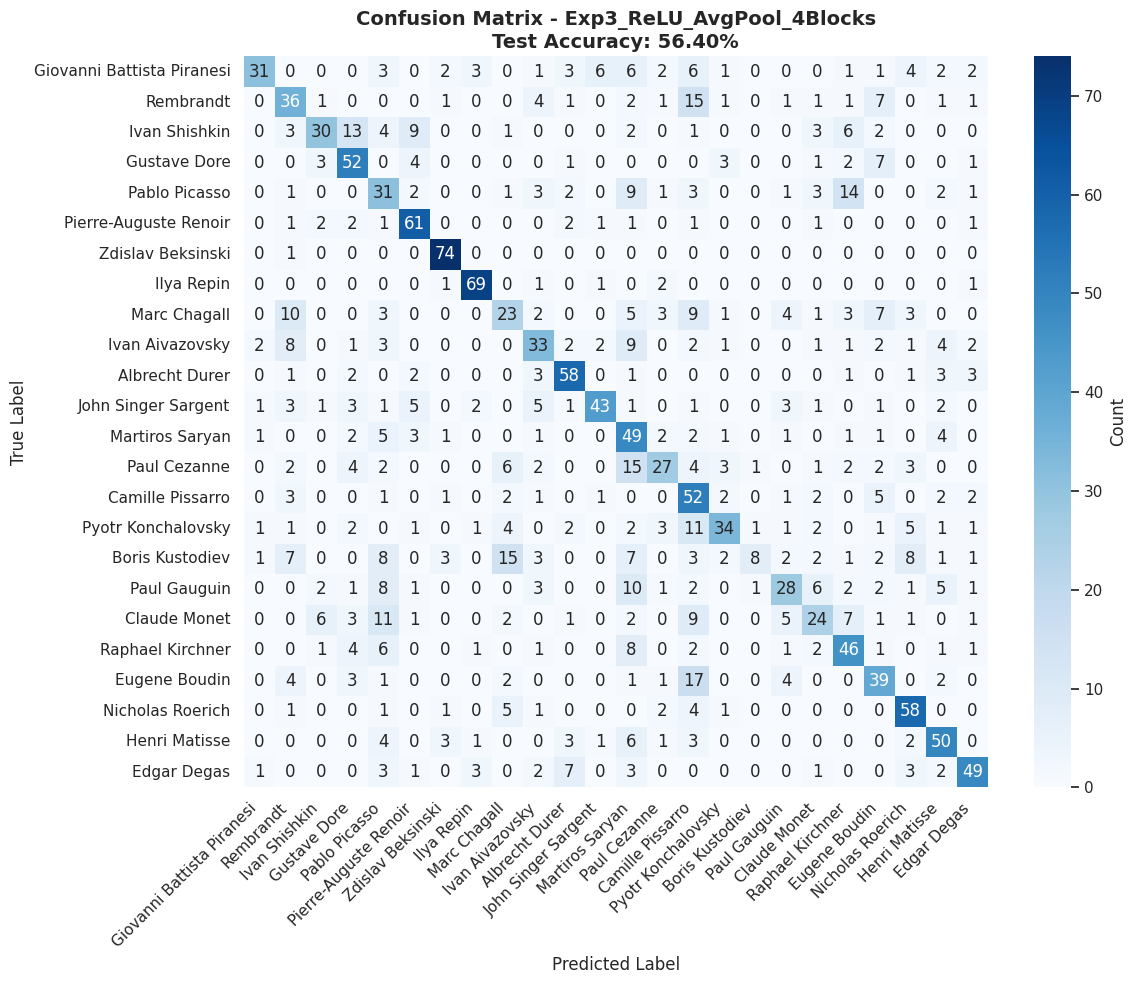

In [57]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
%%time
exp_name = "Exp4_ELU_MaxPool_4Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='elu',
    pooling='max',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=50,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)


best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'ReLU, AvgPool, 4 blocks'
})



Exp4_ELU_MaxPool_4Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 39
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 40
   Best Val Acc so far: 56.50%
   Early stopping counter: 5/15

🚀 Training: Exp4_ELU_MaxPool_4Blocks
📦 BATCH 5: Epochs 41 to 50
   ⚠️  EarlyStopping: 6/15
Epoch  41/50 | TL: 1.8415 TA: 54.54% | VL: 1.8494 VA: 54.44%
   💾 State saved at epoch 40
   ⚠️  EarlyStopping: 7/15
Epoch  42/50 | TL: 1.8256 TA: 56.32% | VL: 1.8239 VA: 56.60%
   💾 State saved at epoch 41
   ⚠️  EarlyStopping: 8/15
Epoch  43/50 | TL: 1.8188 TA: 55.55% | VL: 1.9198 VA: 52.22%
   💾 State saved at epoch 42
   ⚠️  EarlyStopping: 9/15
Epoch  44/50 | TL: 1.7835 TA: 57.61% | VL: 1.8735 VA: 54.04%
   💾 State saved at epoch 43
   ⚠️  EarlyStopping: 10/15
Epoch  45/50 | TL: 1.7730 TA: 57.49% | VL: 2.0939 VA: 47.41%
   💾 State saved at epoch 44
   ✅ Val loss: 1.8026 → 1.7847
Epoch  46/50 | TL: 1.7765 TA: 58.00% | VL: 1.7847 VA: 56.94%
   💾 State saved a


📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.55      0.55      0.55        74
                 Rembrandt       0.42      0.24      0.31        74
             Ivan Shishkin       0.53      0.53      0.53        74
              Gustave Dore       0.69      0.78      0.73        74
             Pablo Picasso       0.34      0.38      0.36        74
     Pierre-Auguste Renoir       0.63      0.93      0.75        74
         Zdislav Beksinski       0.72      0.95      0.82        75
                Ilya Repin       0.76      0.93      0.84        75
              Marc Chagall       0.47      0.45      0.46        74
           Ivan Aivazovsky       0.58      0.35      0.44        74
            Albrecht Durer       0.82      0.77      0.79        75
       John Singer Sargent       0.66      0.66      0.66        74
           Martiros Saryan       0.45      0.49      0.47        74
              Paul Cez

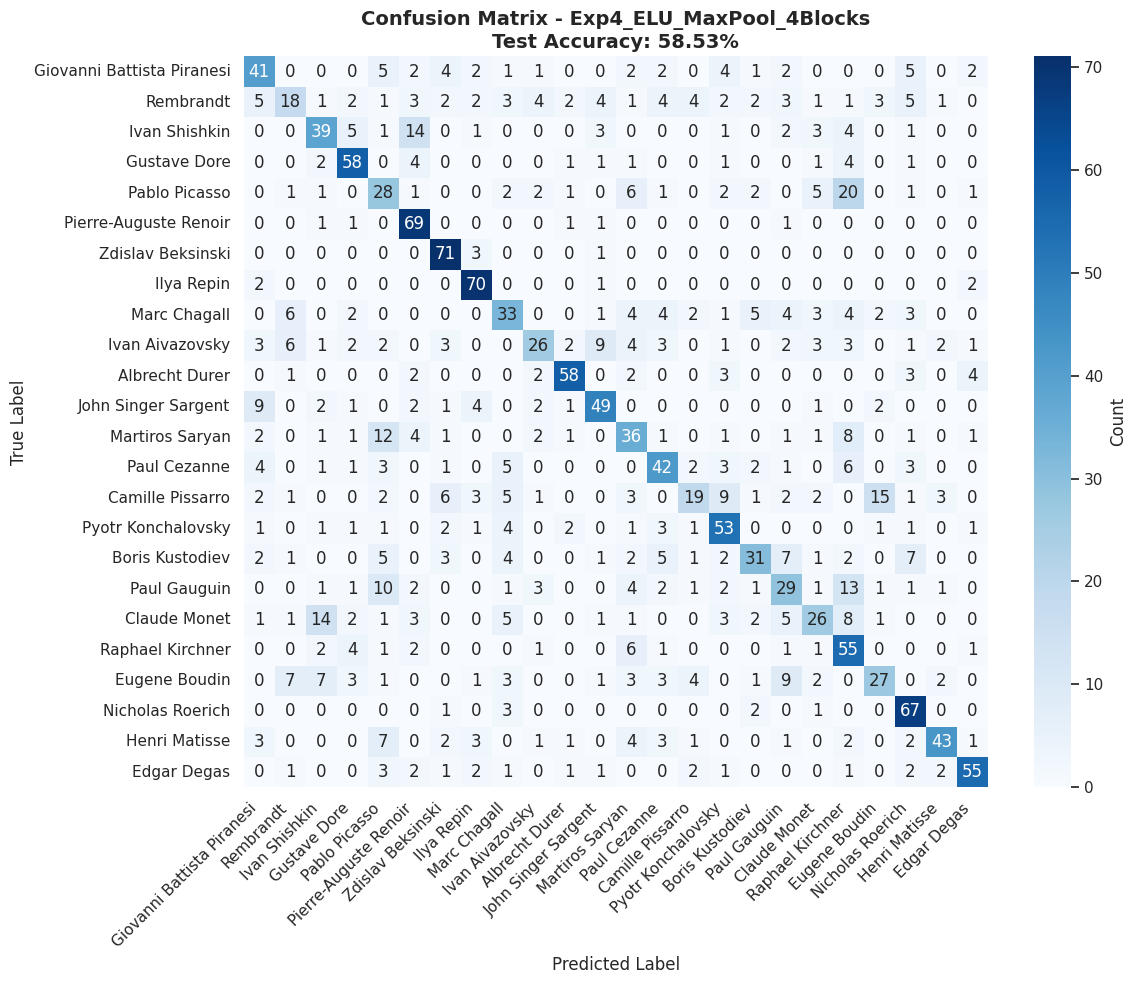

In [63]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [69]:
%%time
exp_name = "Exp5_GELU_MaxPool_4Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='gelu',
    pooling='max',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=50,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)


best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'ReLU, AvgPool, 4 blocks'
})




Exp5_GELU_MaxPool_4Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 39
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 40
   Best Val Acc so far: 64.75%
   Early stopping counter: 1/15

🚀 Training: Exp5_GELU_MaxPool_4Blocks
📦 BATCH 5: Epochs 41 to 50
   ⚠️  EarlyStopping: 2/15
Epoch  41/50 | TL: 1.4780 TA: 70.14% | VL: 1.7396 VA: 60.27%
   💾 State saved at epoch 40
   ⚠️  EarlyStopping: 3/15
Epoch  42/50 | TL: 1.4623 TA: 70.53% | VL: 1.6714 VA: 61.99%
   💾 State saved at epoch 41
   ⚠️  EarlyStopping: 4/15
Epoch  43/50 | TL: 1.4420 TA: 70.98% | VL: 1.6383 VA: 63.20%
   💾 State saved at epoch 42
   ⚠️  EarlyStopping: 5/15
Epoch  44/50 | TL: 1.4176 TA: 72.32% | VL: 1.8884 VA: 54.11%
   💾 State saved at epoch 43
   ⚠️  EarlyStopping: 6/15
Epoch  45/50 | TL: 1.4203 TA: 72.70% | VL: 2.0304 VA: 51.92%
   💾 State saved at epoch 44
   ⚠️  EarlyStopping: 7/15
Epoch  46/50 | TL: 1.4080 TA: 72.51% | VL: 1.7144 VA: 60.64%
   💾 State saved at e


📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.65      0.69      0.67        74
                 Rembrandt       0.43      0.64      0.51        74
             Ivan Shishkin       0.65      0.72      0.68        74
              Gustave Dore       0.69      0.82      0.75        74
             Pablo Picasso       0.54      0.59      0.56        74
     Pierre-Auguste Renoir       0.84      0.78      0.81        74
         Zdislav Beksinski       1.00      0.95      0.97        75
                Ilya Repin       1.00      0.85      0.92        75
              Marc Chagall       0.60      0.57      0.58        74
           Ivan Aivazovsky       0.52      0.62      0.57        74
            Albrecht Durer       0.76      0.85      0.81        75
       John Singer Sargent       0.82      0.69      0.75        74
           Martiros Saryan       0.76      0.46      0.57        74
              Paul Cez

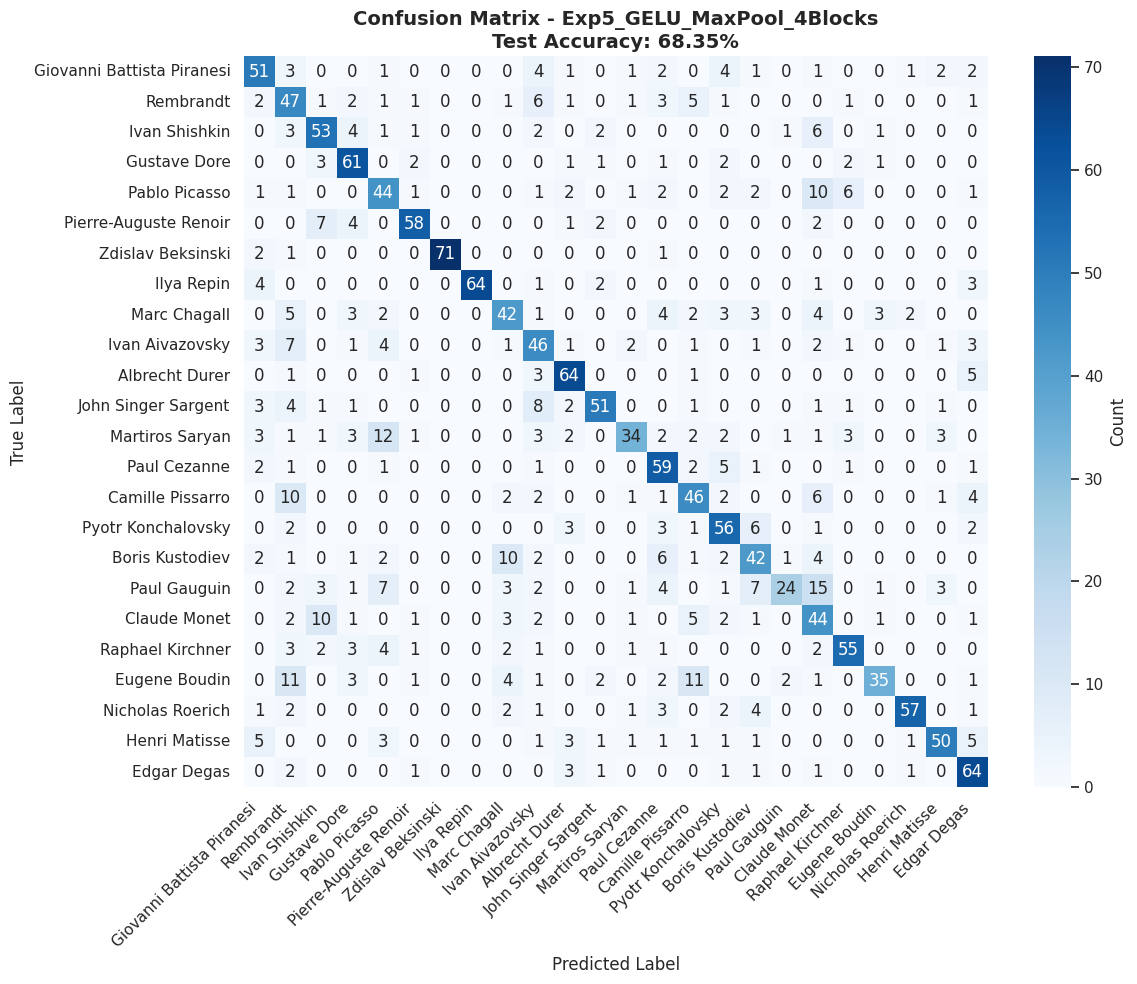

In [70]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [88]:
%%time
exp_name = "Exp6_ReLU_MaxPool_5Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='relu',
    pooling='max',
    num_blocks=5,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=50,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)


best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'ReLU, MaxpoolPool, 5 blocks'
})



Exp6_ReLU_MaxPool_5Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 49
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 50
   Best Val Acc so far: 59.19%
   Early stopping counter: 6/15

🚀 Training: Exp6_ReLU_MaxPool_5Blocks
📦 BATCH 6: Epochs 51 to 50

✅ Batch 6 complete!
✅ Best Val Acc: 59.19%

🎉 Training complete or early stopped!


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


🎯 Test Accuracy: 58.25%
✅ Results saved for: Exp6_ReLU_MaxPool_5Blocks
CPU times: user 4.57 s, sys: 52 ms, total: 4.62 s
Wall time: 4.12 s



📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.59      0.50      0.54        74
                 Rembrandt       0.42      0.35      0.38        74
             Ivan Shishkin       0.45      0.58      0.51        74
              Gustave Dore       0.66      0.72      0.69        74
             Pablo Picasso       0.47      0.46      0.47        74
     Pierre-Auguste Renoir       0.60      0.84      0.70        74
         Zdislav Beksinski       0.75      0.99      0.85        75
                Ilya Repin       0.91      0.93      0.92        75
              Marc Chagall       0.44      0.38      0.41        74
           Ivan Aivazovsky       0.43      0.51      0.47        74
            Albrecht Durer       0.78      0.84      0.81        75
       John Singer Sargent       0.50      0.88      0.64        74
           Martiros Saryan       0.49      0.34      0.40        74
              Paul Cez

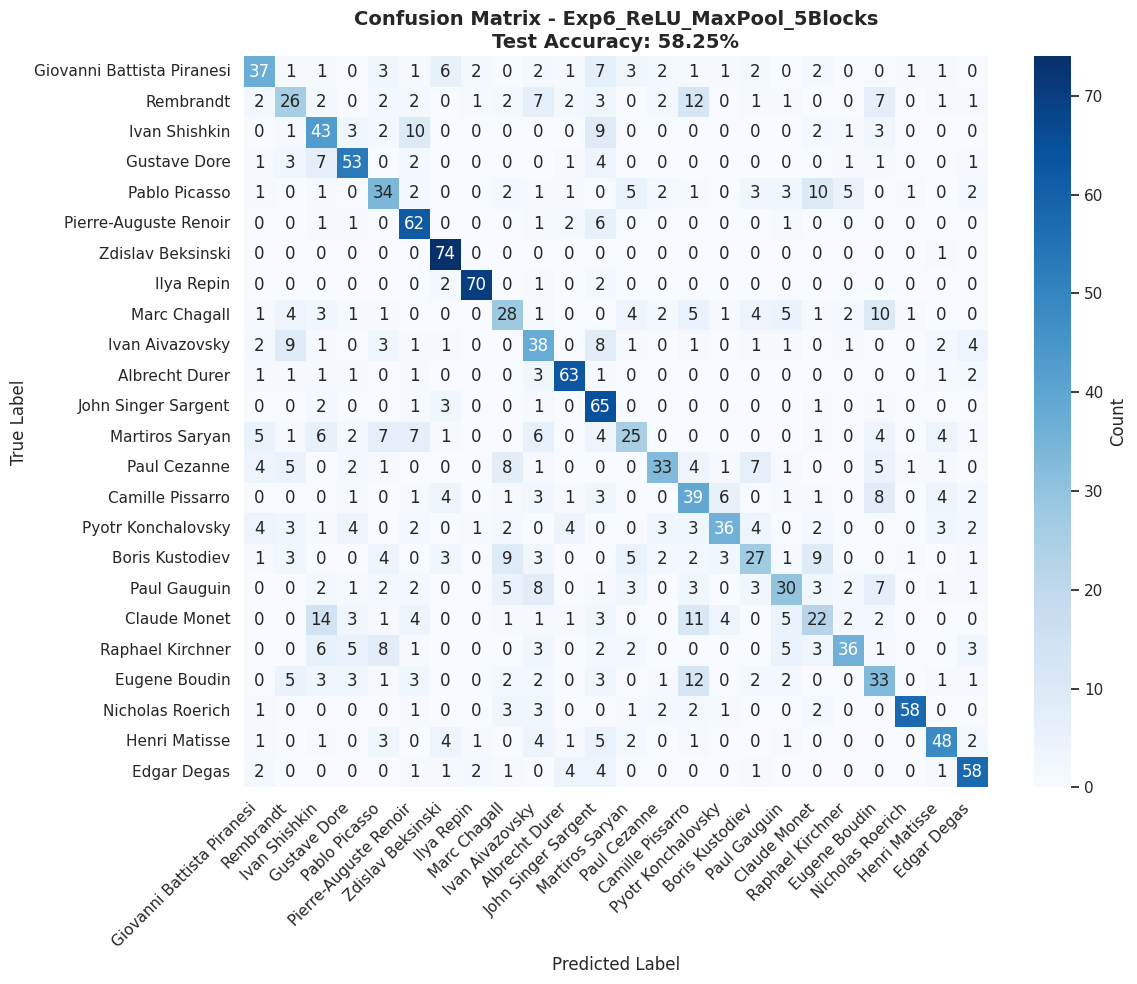

In [79]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [91]:
import shutil
import os
from pathlib import Path

# Define paths
checkpoint_dir = '/kaggle/working/checkpoints'
output_zip = '/kaggle/working/checkpoints_backup2'  # Don't add .zip, shutil adds it

# Check if checkpoints directory exists
if os.path.exists(checkpoint_dir):
    print(f"📦 Creating zip archive of {checkpoint_dir}...")
    
    # Create the zip file (will create checkpoints_backup.zip)
    shutil.make_archive(output_zip, 'zip', checkpoint_dir)
    
    # Verify the zip was created
    zip_path = f"{output_zip}.zip"
    if os.path.exists(zip_path):
        zip_size = os.path.getsize(zip_path) / (1024 * 1024)  # Size in MB
        print(f"✅ Zip created successfully!")
        print(f"📍 Location: {zip_path}")
        print(f"📊 Size: {zip_size:.2f} MB")
        
        # List files in the checkpoints folder
        files = list(Path(checkpoint_dir).glob('*'))
        print(f"\n📁 Archived {len(files)} files:")
        for f in files[:10]:  # Show first 10 files
            print(f"   - {f.name}")
        if len(files) > 10:
            print(f"   ... and {len(files) - 10} more files")
    else:
        print("❌ Failed to create zip file")
else:
    print(f"❌ Checkpoints directory not found at {checkpoint_dir}")

📦 Creating zip archive of /kaggle/working/checkpoints...
✅ Zip created successfully!
📍 Location: /kaggle/working/checkpoints_backup2.zip
📊 Size: 489.35 MB

📁 Archived 21 files:
   - Exp5_GELU_MaxPool_4Blocks_best.pt
   - Exp5_GELU_MaxPool_4Blocks_training_state.json
   - Exp4_ELU_MaxPool_4Blocks_model.pt
   - Exp3_ReLU_AvgPool_4Blocks_model.pt
   - Exp7_ReLU_MaxPool_3Blocks_model.pt
   - Exp1_ReLU_MaxPool_4Blocks_best.pt
   - Exp5_GELU_MaxPool_4Blocks_model.pt
   - Exp6_ReLU_MaxPool_5Blocks_best.pt
   - Exp3_ReLU_AvgPool_4Blocks_training_state.json
   - Exp6_ReLU_MaxPool_5Blocks_training_state.json
   ... and 11 more files


In [85]:
%%time
exp_name = "Exp7_ReLU_MaxPool_3Blocks"
print(f"\n{'='*70}\n{exp_name}\n{'='*70}")

model = FlexibleCNN(
    num_classes=len(artists),
    activation='relu',
    pooling='max',
    num_blocks=3,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True, min_lr=1e-6
)
loss_fn = LabelSmoothingCrossEntropy(smoothing=0.1)

t_loss, v_loss, t_acc, v_acc, best_val = train_model_resumable(
    model, train_loader, val_loader, optimizer, scheduler, 
    total_epochs=50,           # Total epochs
    loss_fn=loss_fn,
    device=device, 
    patience=15, 
    model_name=exp_name, 
    epochs_per_batch=10,       # Run 10 epochs per cell execution
    verbose_ct=1,
    resume=True                # Auto-resume if checkpoint exists
)


best_model_path = f'checkpoints/{exp_name}_best.pt'
model.load_state_dict(torch.load(best_model_path))

preds, labels_true, test_acc = evaluate_model(model, test_loader, device)
print(f"🎯 Test Accuracy: {test_acc:.2f}%")

save_experiment_result(exp_name, {
    'best_val_acc': best_val,
    'test_acc': test_acc,
    'config': 'ReLU, maxool, 3 blocks'
})




Exp7_ReLU_MaxPool_3Blocks
🔍 Kaggle detected: Saving to /kaggle/working/checkpoints/
   📂 Loaded state from epoch 39
   ✅ Model loaded from checkpoint

🔄 RESUMING from epoch 40
   Best Val Acc so far: 62.36%
   Early stopping counter: 2/15

🚀 Training: Exp7_ReLU_MaxPool_3Blocks
📦 BATCH 5: Epochs 41 to 50
   ⚠️  EarlyStopping: 3/15
Epoch  41/50 | TL: 1.7181 TA: 60.67% | VL: 1.8251 VA: 57.64%
   💾 State saved at epoch 40
   ⚠️  EarlyStopping: 4/15
Epoch  42/50 | TL: 1.7145 TA: 60.78% | VL: 1.7158 VA: 59.09%
   💾 State saved at epoch 41
   ⚠️  EarlyStopping: 5/15
Epoch  43/50 | TL: 1.6991 TA: 61.86% | VL: 1.7450 VA: 59.46%
   💾 State saved at epoch 42
   ⚠️  EarlyStopping: 6/15
Epoch  44/50 | TL: 1.7139 TA: 61.27% | VL: 1.7203 VA: 60.57%
   💾 State saved at epoch 43
   ⚠️  EarlyStopping: 7/15
Epoch  45/50 | TL: 1.6773 TA: 62.49% | VL: 1.7672 VA: 59.90%
   💾 State saved at epoch 44
   ⚠️  EarlyStopping: 8/15
Epoch  46/50 | TL: 1.6643 TA: 62.96% | VL: 1.7700 VA: 58.82%
   💾 State saved at e


📊 CLASSIFICATION REPORT
                            precision    recall  f1-score   support

Giovanni Battista Piranesi       0.60      0.65      0.62        74
                 Rembrandt       0.61      0.55      0.58        74
             Ivan Shishkin       0.62      0.54      0.58        74
              Gustave Dore       0.56      0.82      0.67        74
             Pablo Picasso       0.57      0.59      0.58        74
     Pierre-Auguste Renoir       0.71      0.86      0.78        74
         Zdislav Beksinski       1.00      0.93      0.97        75
                Ilya Repin       0.92      0.95      0.93        75
              Marc Chagall       0.58      0.59      0.59        74
           Ivan Aivazovsky       0.57      0.46      0.51        74
            Albrecht Durer       0.80      0.89      0.84        75
       John Singer Sargent       0.83      0.65      0.73        74
           Martiros Saryan       0.57      0.53      0.55        74
              Paul Cez

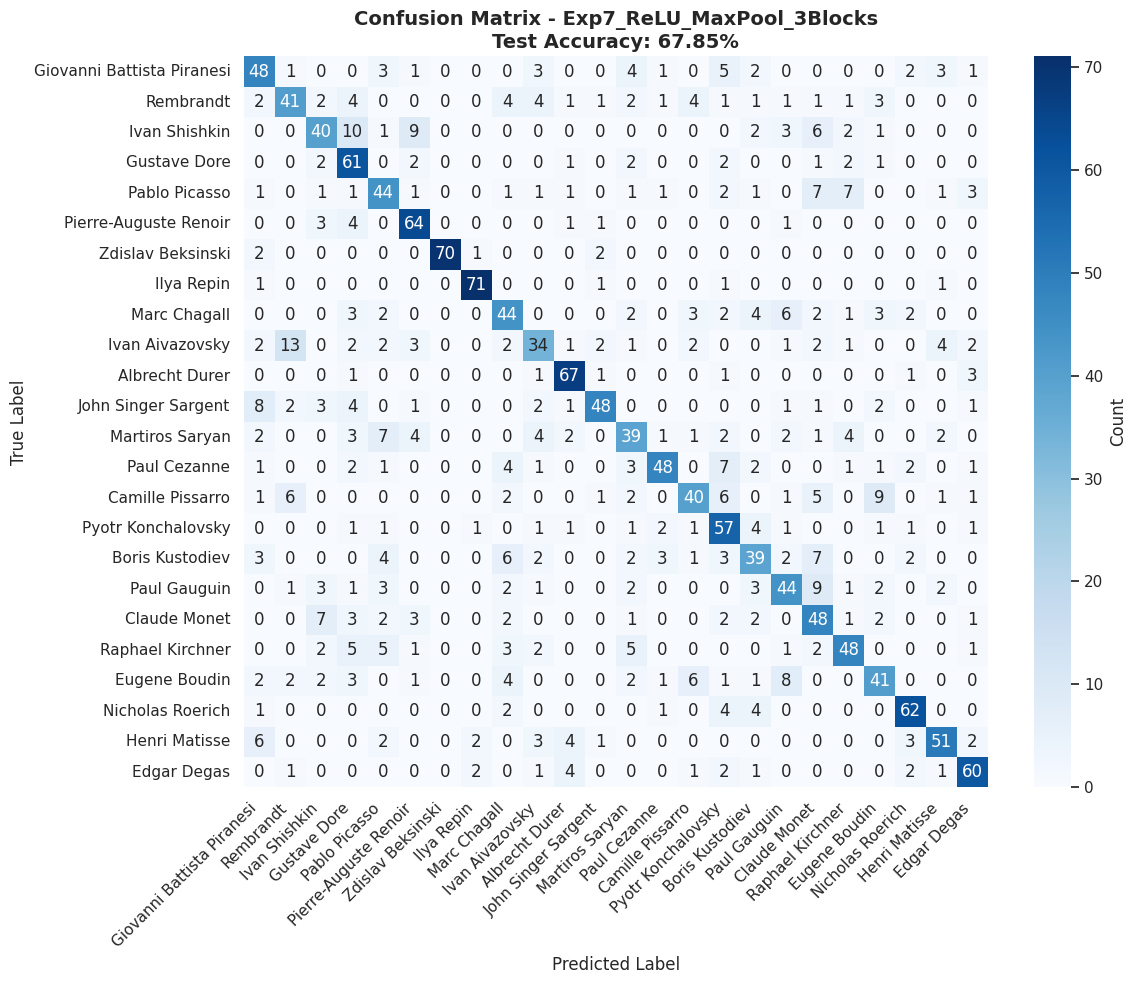

In [86]:
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT")
print("="*70)
print(classification_report(labels_true, preds, target_names=artists))

# Confusion Matrix
cm = confusion_matrix(labels_true, preds)

# Plot Confusion Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=artists, yticklabels=artists,
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {exp_name}\nTest Accuracy: {test_acc:.2f}%', 
          fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [87]:
compare_all_experiments()

# Save comparison to file
import json
with open('experiment_results.json', 'w') as f:
    json.dump(experiment_results, f, indent=4)
print("\n✅ All results saved to 'experiment_results.json'")


EXPERIMENT COMPARISON
Experiment                          Best Val Acc    Test Acc       
--------------------------------------------------------------------------------
Exp1_ReLU_MaxPool_4Blocks                  67.10%          66.16%
exp2_LeakyReLU_MaxPool_4Blocks             66.23%          66.78%
Exp3_ReLU_AvgPool_4Blocks                  55.82%          56.40%
Exp4_ELU_MaxPool_4Blocks                   59.12%          58.53%
Exp5_GELU_MaxPool_4Blocks                  67.54%          68.35%
Exp6_ReLU_MaxPool_5Blocks                  59.19%          58.25%
Exp7_ReLU_MaxPool_3Blocks                  67.81%          67.85%

✅ All results saved to 'experiment_results.json'


In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# ============================================================================
# 1️⃣ LOAD YOUR SAVED MODEL
# ============================================================================

def load_trained_model(checkpoint_path, model_architecture, device='cuda'):
    """
    Load a trained model from checkpoint
    
    Args:
        checkpoint_path: Path to the .pt file (e.g., 'checkpoints/exp2_LeakyReLU_MaxPool_4Blocks_best.pt')
        model_architecture: Your model class instance
        device: 'cuda' or 'cpu'
    """
    print(f"📂 Loading model from: {checkpoint_path}")
    
    # Load the state dict
    model_architecture.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model_architecture.to(device)
    model_architecture.eval()  # Set to evaluation mode
    
    print("✅ Model loaded successfully!")
    return model_architecture


# ============================================================================
# 2️⃣ EVALUATE ON TEST SET
# ============================================================================

def evaluate_and_visualize(model, test_loader, class_names, device='cuda'):
    """
    Evaluate model on test set and show predictions
    """
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    print("🔍 Evaluating on test set...")
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    # Calculate accuracy
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"🎯 Test Accuracy: {accuracy:.2f}%")
    
    return all_preds, all_labels, all_probs


# ============================================================================
# 3️⃣ VISUALIZE PREDICTIONS
# ============================================================================

def show_predictions(model, test_loader, class_names, device='cuda', num_images=12):
    """
    Show sample predictions with confidence scores
    """
    model.eval()
    
    # Get one batch
    images, labels = next(iter(test_loader))
    images, labels = images.to(device), labels.to(device)
    
    with torch.no_grad():
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        confidences, predictions = torch.max(probs, 1)
    
    # Plot
    fig, axes = plt.subplots(3, 4, figsize=(15, 12))
    axes = axes.ravel()
    
    for idx in range(min(num_images, len(images))):
        # Denormalize image for display
        img = images[idx].cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Get prediction info
        true_label = class_names[labels[idx].item()]
        pred_label = class_names[predictions[idx].item()]
        confidence = confidences[idx].item() * 100
        
        # Determine color (green if correct, red if wrong)
        color = 'green' if predictions[idx] == labels[idx] else 'red'
        
        # Plot
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(
            f'True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%',
            color=color, fontsize=10, fontweight='bold'
        )
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/predictions_demo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Visualization saved to: /kaggle/working/predictions_demo.png")


# ============================================================================
# 4️⃣ SHOW CONFUSION MATRIX
# ============================================================================

def plot_confusion_matrix(true_labels, predictions, class_names):
    """
    Plot confusion matrix
    """
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    
    cm = confusion_matrix(true_labels, predictions)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Confusion matrix saved to: /kaggle/working/confusion_matrix.png")


# ============================================================================
# 📊 MAIN DEMO CODE - RUN THIS DURING PRESENTATION
# ============================================================================

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
checkpoint_path = '/kaggle/working/checkpoints/exp2_LeakyReLU_MaxPool_4Blocks_best.pt'

# Assuming you have these defined (class_names and test_loader)
# class_names = ['Artist1', 'Artist2', ...]  # Your artist names
# test_loader = DataLoader(...)  # Your test dataset

print("=" * 70)
print("🎨 ARTIST CLASSIFICATION MODEL DEMO")
print("=" * 70)

# Step 1: Initialize model architecture (same as training)
model = FlexibleCNN(
    num_classes=len(artists),  # Or replace with actual number
    activation='leakyrelu',
    pooling='max',
    num_blocks=4,
    dropout=0.5,
    channels=[64, 128, 256, 512, 512]
).to(device)

# Step 2: Load trained weights
model = load_trained_model(checkpoint_path, model, device)

# Step 3: Evaluate on test set
preds, labels_true, probs = evaluate_and_visualize(model, test_loader, artists, device)

# Step 4: Show sample predictions
print("\n📸 Generating sample predictions...")
show_predictions(model, test_loader, artists, device, num_images=12)

# Step 5: Show confusion matrix
print("\n📊 Generating confusion matrix...")
plot_confusion_matrix(labels_true, preds, artists)

print("\n" + "=" * 70)
print("✅ DEMO COMPLETE!")
print("=" * 70)